In [40]:
import keras
from keras import layers, Sequential, models
from keras.layers import Dense, MaxPooling2D, Conv2D

import warnings
warnings.filterwarnings('ignore')

### Splitting the dataset into training and validation

In [41]:
path = "/kaggle/input/datasets/mattop/panda-or-bear-image-classification/PandasBears/Train"

train_ds = keras.utils.image_dataset_from_directory(
    path,
    batch_size=64,
    color_mode='rgb',
    shuffle=True,
    validation_split=0.2,
    label_mode='int',
    seed=42,
    subset='training',
    image_size=(128,128)
)

val_ds = keras.utils.image_dataset_from_directory(
    path,
    batch_size=64,
    color_mode='rgb',
    shuffle=True,
    validation_split=0.2,
    label_mode='int',
    seed=42,
    subset='validation',
    image_size=(128,128)
)


Found 500 files belonging to 2 classes.
Using 400 files for training.
Found 500 files belonging to 2 classes.
Using 100 files for validation.


### Printing imgs from the batch

In [42]:
import matplotlib.pyplot as plt

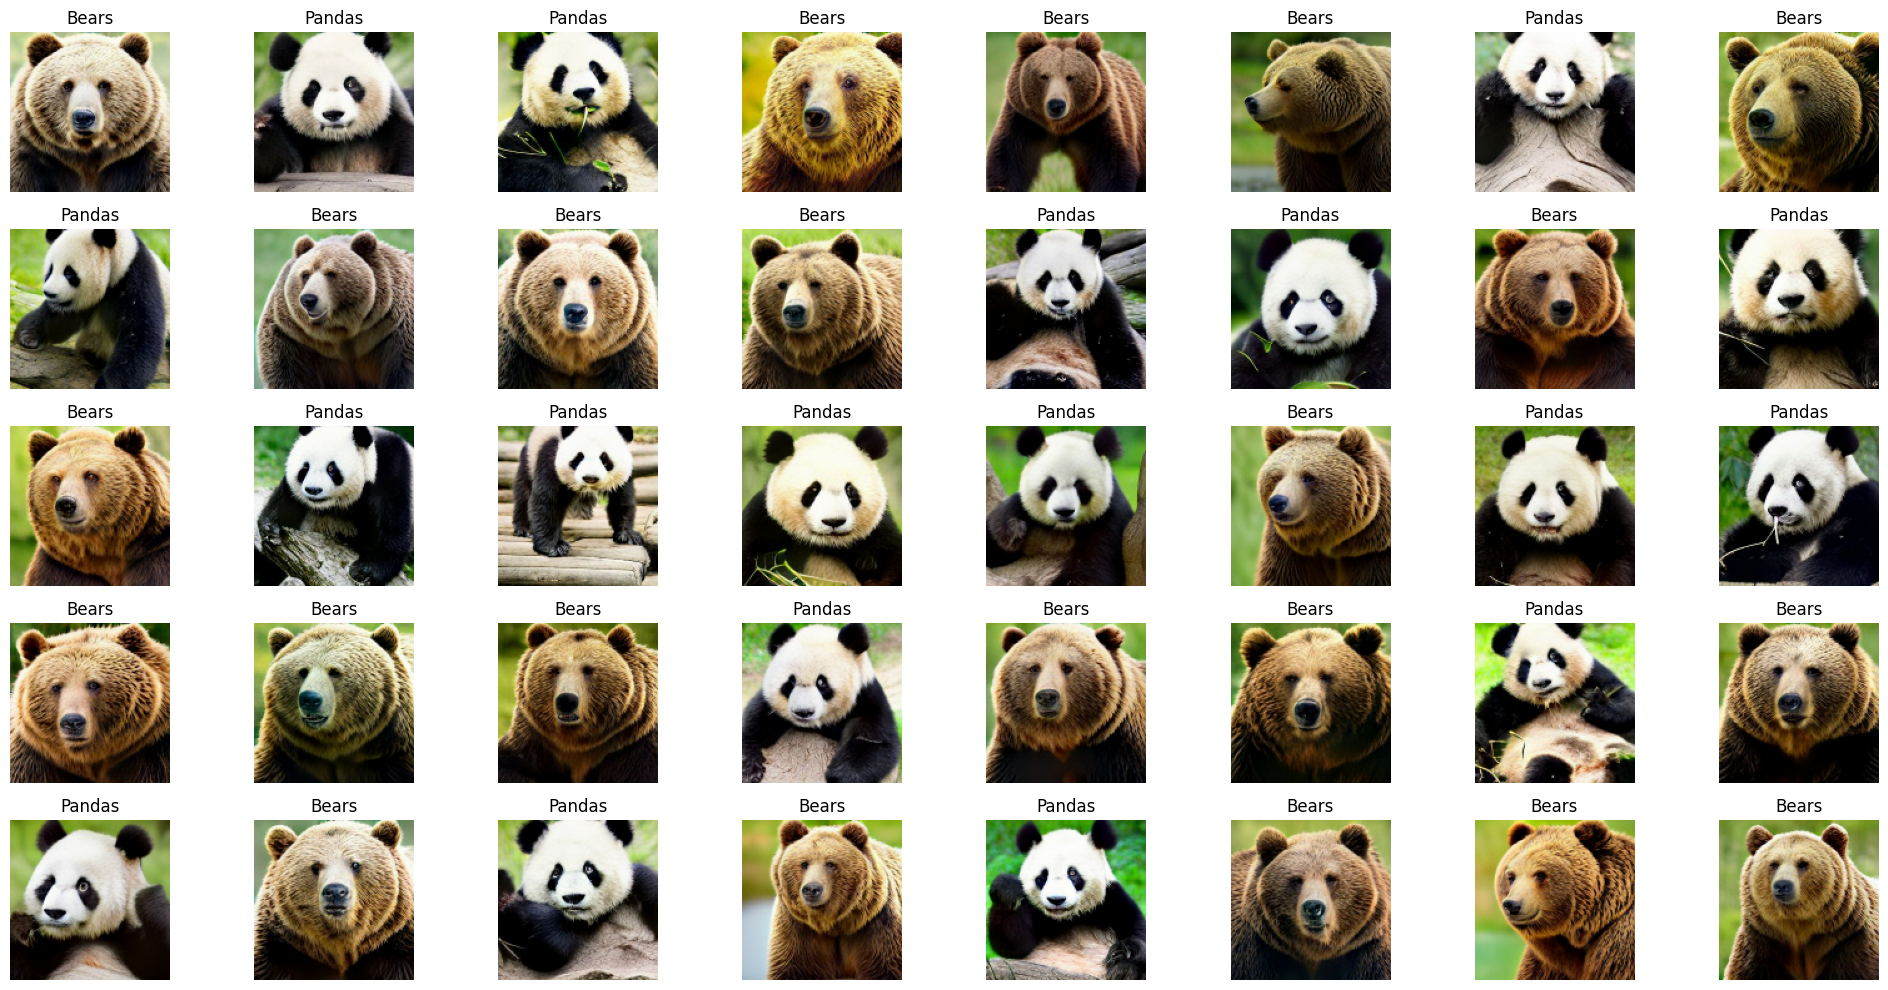

In [43]:
for imgs, labels in train_ds.take(1):
    plt.figure(figsize=(20,10))

    for i in range(40):
        ax = plt.subplot(5,8,i+1)
        plt.imshow(imgs[i].numpy().astype('uint8'))
        label_name = labels[i].numpy()
        plt.title(train_ds.class_names[label_name])
        plt.axis('off')

plt.tight_layout()
plt.show()

**Observation** : As we have seen above there is only bear of one specific color (brown) is available, but in reality there is also Indian black color bear available.

## **Creating full `optuna` model**

### Creating a class to do Pruning

In [44]:
import optuna

In [45]:
class PyKerasPruningCallback(keras.callbacks.Callback):
    def __init__(self, trial, monitor='val_accuracy'):
        super().__init__()
        self.trial = trial
        self.monitor = monitor

    def on_epoch_end(self, epoch, logs=None):
        log = logs or {}
        val = log.get(self.monitor)

        if val is None:
            return
        
        self.trial.report(val, epoch)

        if self.trial.should_prune():
            message = f"Trial pruned at epoch {epoch}."
            raise optuna.exceptions.TrialPruned(message)

### Creating `optuna` function 

In [46]:
from keras import regularizers

In [ ]:
def create_optuna_model(trial):
    keras.backend.clear_session()                                        # clearing all the previous sessions of keras, and stored memory

    # setting different parameters
    conv_layers = trial.suggest_int('conv_layers', 1,5)                    # for conv layers
    dense_layers = trial.suggest_int('dense_layers', 1,4)                  # for dense layers 
    l2_reg = trial.suggest_float('l2_reg',1e-4, 1e-2, log=True)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)

    
    temp_list = [
        layers.RandomFlip('horizontal', input_shape=(128,128,3)),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.3),
        layers.Rescaling(1./255)
    ]

    count = 0
    for i in range(conv_layers):
        if count == 0:
            filters = trial.suggest_int(f'filter_{i}',16,64,step=16)
            temp_list.append(layers.Conv2D(filters=filters, kernel_size=(3,3), padding='same', activation='relu'))
            temp_list.append(layers.MaxPooling2D(pool_size=(2,2)))
            count += 1
        else:
            filters = trial.suggest_int(f'filter_{i}',32,160,step=20)
            temp_list.append(layers.Conv2D(filters=filters, kernel_size=(3,3), padding='same', activation='relu'))
            temp_list.append(layers.MaxPooling2D(pool_size=(2,2)))

    # Applying Flatten
    temp_list.append(layers.Flatten())

    # The below code ensures that the number of neurons will be in a decreasing order (for optimal output)
    first_neurons = trial.suggest_int('neuron_0', 32, 128, step=32)
    temp_list.append(layers.Dense(first_neurons, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)))
    temp_list.append(layers.Dropout(rate=dropout_rate))

    for i in range(1, dense_layers):
        neurons = trial.suggest_int(f'neuron_{i}', 16, first_neurons, step=16)
        temp_list.append(layers.Dense(neurons, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)))
        temp_list.append(layers.Dropout(rate=dropout_rate))

    
    # final layer output with 1 neuron
    temp_list.append(
        layers.Dense(1, activation='sigmoid')
    )

    # ------------------------------------------------------------------------------------------------------------------------------------
    # ------------------------------------------------------------------------------------------------------------------------------------
    
    model = Sequential(temp_list)

    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=lr),
        loss = 'binary_crossentropy',
        metrics = ['accuracy'],
    )

    return model


# Creating `objective` function

In [48]:
def objective(trial):
    model = create_optuna_model(trial)
    pruning_callback = PyKerasPruningCallback(trial, monitor='val_accuracy')

    history = model.fit(
        train_ds,
        validation_data = val_ds,
        epochs = 15,
        callbacks = [pruning_callback],
        verbose=0
    )

    return max(history.history['val_accuracy'])

### Creating a `study` and then `optimizing` the model

In [50]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(multivariate=True), pruner=optuna.pruners.HyperbandPruner())
study.optimize(objective, n_trials=20)

[I 2026-06-12 18:04:43,611] A new study created in memory with name: no-name-4a3f6ca2-c010-49bd-bb2a-3964abd7c779
[I 2026-06-12 18:04:52,846] Trial 0 finished with value: 1.0 and parameters: {'conv_layers': 2, 'dense_layers': 1, 'l2_reg': 0.00018435939063154825, 'lr': 0.002266083385315689, 'dropout_rate': 0.41965770772992894, 'filter_0': 32, 'filter_1': 152, 'neuron_0': 64}. Best is trial 0 with value: 1.0.
[I 2026-06-12 18:05:04,714] Trial 1 finished with value: 1.0 and parameters: {'conv_layers': 3, 'dense_layers': 4, 'l2_reg': 0.000130158819781803, 'lr': 0.00044813973333036357, 'dropout_rate': 0.4586055183668519, 'filter_0': 48, 'filter_1': 152, 'filter_2': 52, 'neuron_0': 32, 'neuron_1': 16, 'neuron_2': 16, 'neuron_3': 16}. Best is trial 0 with value: 1.0.
[I 2026-06-12 18:05:16,854] Trial 2 finished with value: 1.0 and parameters: {'conv_layers': 4, 'dense_layers': 3, 'l2_reg': 0.00011219355616772373, 'lr': 0.00021357458455997092, 'dropout_rate': 0.18750347111496612, 'filter_0': 4

In [52]:
print(f"BEST ACCURACY : {study.best_trial.value}")
print(f"BEST PARAMETERS : {study.best_trial.params}")

BEST ACCURACY : 1.0
BEST PARAMETERS : {'conv_layers': 2, 'dense_layers': 1, 'l2_reg': 0.00018435939063154825, 'lr': 0.002266083385315689, 'dropout_rate': 0.41965770772992894, 'filter_0': 32, 'filter_1': 152, 'neuron_0': 64}


### Getting the best model and training over the dataset

In [55]:
model = create_optuna_model(study.best_trial)

history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 30
)

Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.5150 - loss: 2.7080 - val_accuracy: 0.4700 - val_loss: 0.6791
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8000 - loss: 0.4935 - val_accuracy: 0.9600 - val_loss: 0.2230
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9800 - loss: 0.2014 - val_accuracy: 0.9500 - val_loss: 0.2700
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9700 - loss: 0.2177 - val_accuracy: 1.0000 - val_loss: 0.1346
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9925 - loss: 0.1537 - val_accuracy: 1.0000 - val_loss: 0.1297
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9950 - loss: 0.1522 - val_accuracy: 1.0000 - val_loss: 0.1204
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9950 - loss: 0.1352 - val_accuracy: 0.9800 - val_loss: 0.1518
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9900 - loss: 0.1295 - val_accuracy: 1.0000 - val_loss: 0.1034


### Visualizing the accuracy and loss

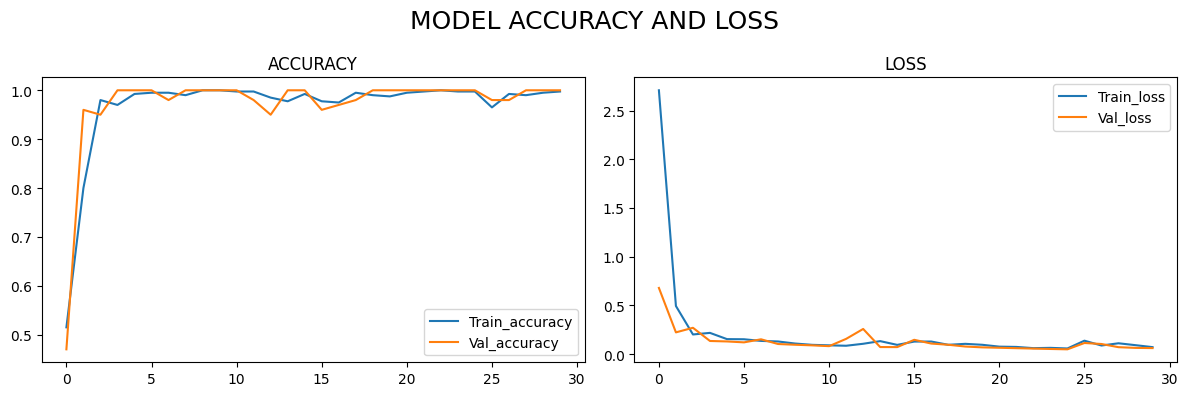

In [59]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train_accuracy')
plt.plot(history.history['val_accuracy'], label='Val_accuracy')
plt.legend()
plt.title('ACCURACY')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train_loss')
plt.plot(history.history['val_loss'], label='Val_loss')
plt.legend()
plt.title('LOSS')

plt.suptitle('MODEL ACCURACY AND LOSS', fontsize=18)
plt.tight_layout()
plt.show()

## Optuna Visualization

In [ ]:
from optuna.visualization.matplotlib  import plot_param_importances, plot_optimization_history, plot_parallel_coordinate, plot_slice, plot_contour

In [66]:
plot_optimization_history(study).show()

In [70]:
plot_slice(study).show()